|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Embedding spaces<h1>|
|<h2>Lecture:</h2>|<h1><b>Multiple videos on learning embeddings<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# typical libraries...
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# for importing and working with texts
import requests
import re
import string

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F

!pip install torchinfo # not installed by default in colab
from torchinfo import summary

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# **Code below is for video "Create a data loader to train a model"**

## Import text and create dictionary

In [2]:
# get raw text from internet (The Time Machine... yeah I use it a lot :P  )
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
# character strings to replace with space
strings2replace = [ '\r\n\r\nâ\x80\x9c','â\x80\x9c','â\x80\x9d','\r\n','â\x80\x94','â\x80\x99','â\x80\x98','_', ]

# use regular expression (re) to replace those strings with space
for str2match in strings2replace:
  text = re.compile(r'%s'%str2match).sub(' ',text)

# remove non-ASCII characters and numbers, and make lower-case
text = re.sub(r'[^\x00-\x7F]+', ' ', text)
text = re.sub('\d+','',text).lower()

# split into words with >1 letter
words = re.split(f'[{string.punctuation}\s]+',text)
words = [item.strip() for item in words if item.strip()]
words = [item for item in words if len(item)>1]

# create the vocabulary (lexicon)
vocab  = sorted(set(words))
nWords = len(words)
nVocab = len(vocab)

# encoder/decoder look-up-tables (as python dictionaries)
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for i,w in enumerate(vocab)}

# show a few keys in the dictionary
print(f'The book contains {nWords:,} words, {nVocab:,} of which are unique and comprise the vocab.')
print(f'\n\nFirst 10 vocab words:\n',list(word2idx.keys())[:10])

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_25/2659864497.py:12: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+','',text).lower()
/tmp/ipykernel_25/2659864497.py:15: SyntaxWarning: invalid escape sequence '\s'
  words = re.split(f'[{string.punctuation}\s]+',text)


The book contains 30,698 words, 4,589 of which are unique and comprise the vocab.


First 10 vocab words:
 ['abandon', 'abandoned', 'able', 'abnormally', 'abominable', 'abominations', 'about', 'above', 'abruptly', 'absence']


In [3]:
# parameters for dataset
context_length = 8 # context length
stride = 2 # skipping

# initialize
inputs  = []
targets = []

# overlapping sequences of context_length
for i in range(0,nWords-context_length,stride):

  # get a few words
  in_seq   = words[i  : i+context_length  ]
  targ_seq = words[i+1: i+context_length+1]

  # append to the lists
  inputs.append([word2idx[w] for w in in_seq])
  targets.append([word2idx[w] for w in targ_seq])

print(inputs[123])
print(targets[123])

[1342, 4304, 4119, 342, 4296, 3388, 1474, 131]
[4304, 4119, 342, 4296, 3388, 1474, 131, 209]


In [4]:
# a closer look:
print('Inputs: ',inputs[4])
print('Targets:',targets[4])
print('')
print('Inputs :',inputs[5])
print('Targets:',targets[5])
# this is what we need, although we need it in torch Dataset/DataLoader format

Inputs:  [2416, 131, 2172, 506, 4451, 783, 2167, 2005]
Targets: [131, 2172, 506, 4451, 783, 2167, 2005, 4042]

Inputs : [2172, 506, 4451, 783, 2167, 2005, 4042, 2416]
Targets: [506, 4451, 783, 2167, 2005, 4042, 2416, 2006]


In [5]:
# we need each list to be a tensor
torch.tensor(inputs[4])

tensor([2416,  131, 2172,  506, 4451,  783, 2167, 2005])

## Create a class for a dataset object

In [6]:
# create a class for a dataset
class WordDataset(Dataset):
  def __init__(self, text, word2idx, context_length=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []
    self.word2idx = word2idx  # stored locally in the object

    # overlapping sequences of context_length
    for i in range(0,len(text)-context_length,stride):

      # get a few words
      in_seq   = text[i : i+context_length]
      targ_seq = text[i+1 : i+context_length+1]

      # append to the lists
      self.inputs.append(torch.tensor([word2idx[w] for w in in_seq]))
      self.targets.append(torch.tensor([word2idx[w] for w in targ_seq]))

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]


# create an instance!
context_length = 6 # context length
stride = 3 # skipping over tokens
text_dataset = WordDataset(words,word2idx,context_length,stride)

print(text_dataset[4])
print(text_dataset[5])

(tensor([4451,  783, 2167, 2005, 4042, 2416]), tensor([ 783, 2167, 2005, 4042, 2416, 2006]))
(tensor([2005, 4042, 2416, 2006, 4042, 4109]), tensor([4042, 2416, 2006, 4042, 4109, 4171]))


In [7]:
len(text_dataset)

10231

## And a dataloader for training

In [8]:
# also need a dataloader
dataloader = DataLoader(
                text_dataset,
                batch_size = 32, # 2 for looking; 32 for training
                shuffle    = True,
                drop_last  = True
            )

# let's have a look at the indices
X,y = next(iter(dataloader))
print('Inputs:')
print(X), print('')

print('Targets:')
print(y), print('\n\n\n')

# and the words
print('Inputs in words (first batch):')
print([idx2word[item.item()] for item in X[0]])
print('')

print('Targets in words (first batch):')
print([idx2word[item.item()] for item in y[0]])

Inputs:
tensor([[3503, 2731, 4042, 2572,  137, 4058],
        [2272, 4250, 1395, 3756, 3831, 2063],
        [4408, 1112, 4042, 2694, 4408, 3693],
        [ 553, 2764, 3006, 4051, 2468, 2741],
        [2041, 1641, 2731, 4304, 2041, 2245],
        [1474,  131,  209, 2907, 4510, 3209],
        [4170, 2163, 4042, 1659, 3388, 1474],
        [4450, 2347, 2753, 2731, 4466, 1861],
        [ 919, 4461, 4306, 4119,  319, 1573],
        [ 902,  425, 4058, 2586, 1852, 1019],
        [4405, 4045, 4461, 3406, 4043, 2368],
        [ 137, 2186, 4408, 1950, 1498,    6],
        [ 215,  137, 1425, 4463, 2509, 3636],
        [ 930, 1815,  339, 3065,   65,  506],
        [ 592, 1640, 2339, 4119,  391, 2420],
        [4254,  101,  501, 1297, 4467, 4219],
        [ 916,   74, 1424,  137, 1424, 3831],
        [4043, 1318, 1572, 1453, 4071,  137],
        [ 699, 3969, 1815, 4119, 4066, 3155],
        [  74, 4408, 1058,  255, 1492, 3527],
        [ 357, 2186, 3991, 2186,  230, 2332],
        [4041, 4042,  756,

# **Code below is for video "Build a model to learn the embeddings"**

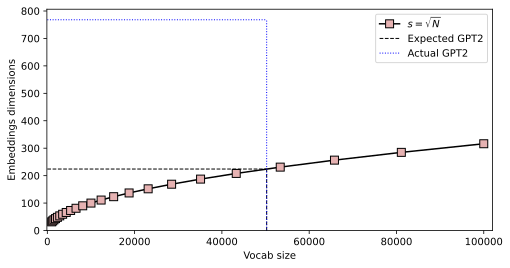

In [9]:
# exploring dimensionality based on vocab sizes

# vocab sizes
N = np.logspace(np.log10(1000),np.log10(100000),23)

# heuristic for non-LLM models like word2vec or glove:
embdim = np.sqrt(N)

# parameters for GPT2
gpt2dims = [ 50257,768 ]

plt.figure(figsize=(8,4))

# heuristic line
plt.plot(N,embdim,'ks-',markersize=8,markerfacecolor=[.9,.7,.7],label=r'$s = \sqrt{N}$')

# expected embedding dim for GPT2
plt.plot([gpt2dims[0],gpt2dims[0]],[0,np.sqrt(gpt2dims[0])],'k--',linewidth=1,label='Expected GPT2')
plt.plot([0,gpt2dims[0]],[np.sqrt(gpt2dims[0]),np.sqrt(gpt2dims[0])],'k--',linewidth=1)

# actual GPT2 embedding
plt.plot([gpt2dims[0],gpt2dims[0]],[0,gpt2dims[1]],'b:',linewidth=1,label='Actual GPT2')
plt.plot([0,gpt2dims[0]],[gpt2dims[1],gpt2dims[1]],'b:',linewidth=1)

plt.gca().set(xlabel='Vocab size',ylabel='Embeddings dimensions',
              xlim=[-100,N[-1]+2000],ylim=[0,None])
plt.legend()
plt.show()

## Create and explore an embedding layer

In [10]:
# dimensionality of embedding space (arbitrarily set to 100)
embeddingDimension = 100

# create a random embedding
embedding_layer = nn.Embedding(nVocab,embeddingDimension)

# let's see its size
embedding_layer.weight.shape

torch.Size([4589, 100])

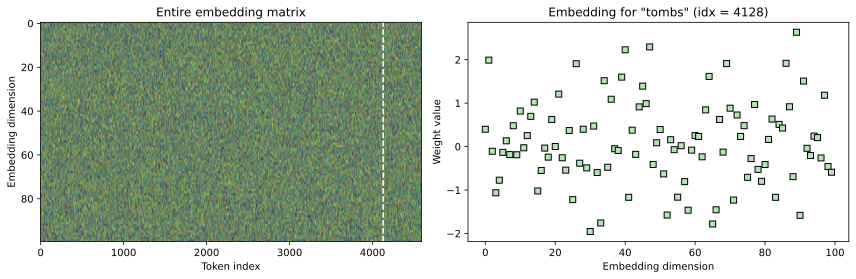

In [11]:
# what does it look like?

_,axs = plt.subplots(1,2,figsize=(12,4))
axs[0].imshow(embedding_layer.weight.detach().T,aspect='auto',vmin=-1,vmax=1)
axs[0].set(ylabel='Embedding dimension',xlabel='Token index',title='Entire embedding matrix')

# pick a word at random
aRandomWord = np.random.choice(vocab)

# plot its embedding
axs[1].plot(embedding_layer.weight.detach()[word2idx[aRandomWord],:],'ks',markerfacecolor=[.7,.9,.7])
axs[0].axvline(word2idx[aRandomWord],color='w',linestyle='--')
axs[1].set(xlabel='Embedding dimension',ylabel='Weight value',title=f'Embedding for "{aRandomWord}" (idx = {word2idx[aRandomWord]})')

plt.tight_layout()
plt.show()

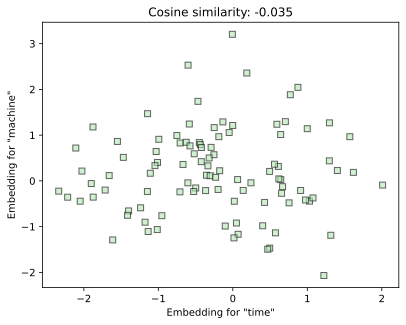

In [12]:
# embeddings for closely related words
word1 = 'time'
word2 = 'machine'

# their embeddings
embed1 = embedding_layer.weight.detach()[word2idx[word1],:]
embed2 = embedding_layer.weight.detach()[word2idx[word2],:]

# cosine similiarity between them
cosSim = torch.dot(embed1,embed2)/(torch.norm(embed1)*torch.norm(embed2))

# vizualize
plt.plot(embed1,embed2,'ks',markerfacecolor=[.7,.9,.7],alpha=.6)
plt.gca().set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
              title=f'Cosine similarity: {cosSim:.3f}')
plt.show()

## Build the model

In [13]:
class EmbeddingModel(nn.Module):
  def __init__(self, vocab_size, embedding_dim, context_size):
    super(EmbeddingModel, self).__init__()

    # embedding layer
    self.embeddings = nn.Embedding(vocab_size, embedding_dim)

    # linear layers
    self.linear1 = nn.Linear(context_size * embedding_dim, 128)
    self.linear2 = nn.Linear(128, vocab_size)

  def forward(self, inputs):

    # extract and flatten embeddings [batch_size, context_size * embedding_dim]
    embeds = self.embeddings(inputs).view(inputs.shape[0],-1)

    # fully connected layers
    out = F.relu(self.linear1(embeds))
    out = self.linear2(out)

    # log softmax for classification (note: NLLLoss expects logprobs as inputs)
    log_probs = F.log_softmax(out, dim=1)
    return log_probs


# create a model instance!
model = EmbeddingModel(vocab_size=nVocab, embedding_dim=embeddingDimension, context_size=context_length)
print(model)

# apply Xavier weight distribution
for param in model.parameters():
  if param.dim()>1: # also excludes biases
    nn.init.xavier_normal_(param)

EmbeddingModel(
  (embeddings): Embedding(4589, 100)
  (linear1): Linear(in_features=600, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=4589, bias=True)
)


In [14]:
# let's test the model

X,y = next(iter(dataloader))
modelOut = model(X)

print('Input to model:')
print(X), print('')

print(f'Output from model (size: {list(modelOut.detach().shape)}):')
print(modelOut)

Input to model:
tensor([[3373, 4352, 3604, 4408, 2608, 1353],
        [2731, 2438,  137, 3406, 2041, 4042],
        [4171,  137, 4119, 4042, 3092, 4581],
        [4194,    6, 4042, 2572,  137, 4408],
        [4042, 2944,  506, 4042,  507, 4408],
        [1972, 2681,  162, 2474, 2731,  448],
        [4042, 4109, 2416,  137, 3880, 1843],
        [  71,   96, 2608, 1235, 3024, 1572],
        [1645,  137, 1815, 1400, 1729, 2731],
        [ 137, 2420, 2578, 4144, 4042, 4500],
        [3311, 4042, 2645, 2731, 4042,  959],
        [4230, 4079, 2726, 4549,  319, 2066],
        [ 137, 4051, 2041, 4042, 3711, 2339],
        [1047, 1828,  137, 3638,  170,  817],
        [ 976, 2602, 4296, 4042, 4059, 3699],
        [4042, 2262, 4041, 4352,  661, 2069],
        [1541, 3406,  501, 2278,  341, 4119],
        [3289, 4119, 4414, 2382,  113, 4133],
        [4218,  113,   12,  580, 4051, 4408],
        [3452, 4042, 2035, 2186,  842, 4495],
        [2726,   66, 1572, 2470, 4190,  137],
        [1144, 405

In [15]:
# log soft-max output:
print(modelOut.detach()[0])
print('')

# shouldn't the sum be 1?
print(f'Log softmax sum = {modelOut.detach()[0].sum():.3f}')

# ah, it's *log* softmax :D
print(f'exp(log(softmax)) sum = {torch.exp(modelOut.detach()[0]).sum():.3f}')

tensor([-8.3592, -8.5055, -8.4743,  ..., -8.3898, -8.3884, -8.4084])

Log softmax sum = -38697.719
exp(log(softmax)) sum = 1.000


In [16]:
# find the word with the highest probability
print('Model input:')
print([idx2word[w.item()] for w in X[0]])
print('')

print('Model output:')
print(idx2word[modelOut[0].argmax().item()])

Model input:
['ruins', 'very', 'simple', 'was', 'my', 'explanation']

Model output:
joint


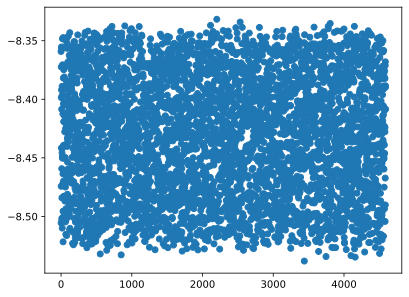

In [17]:
plt.plot(modelOut[0].detach(),'o');

## Have the model generate text

In [18]:
# grab some data from the loader
X,y = next(iter(dataloader))

print('First input:')
print(' '.join([idx2word[w.item()] for w in X[0]]))
print('\nSubsequent inputs:')

# text generation
for _ in range(context_length):

  # get output for this input
  Y = model(X)

  # pick the most likely next word
  nextWord = Y[0].argmax().item()

  # create new input for the next iteration (word)
  X[0] = torch.concatenate((X[0][1:],torch.tensor([nextWord])))

  # print out the generated text so far
  print(' '.join([idx2word[w.item()] for w in X[0]]))

First input:
step forward hesitated and then touched

Subsequent inputs:
forward hesitated and then touched joint
hesitated and then touched joint joint
and then touched joint joint began
then touched joint joint began joint
touched joint joint began joint joint
joint joint began joint joint burslem


## How big is our model?

In [19]:
# summary of model and parameters
summary(model, input_data=X, col_names=['input_size','output_size','num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
EmbeddingModel                           [32, 6]                   [32, 4589]                --
├─Embedding: 1-1                         [32, 6]                   [32, 6, 100]              458,900
├─Linear: 1-2                            [32, 600]                 [32, 128]                 76,928
├─Linear: 1-3                            [32, 128]                 [32, 4589]                591,981
Total params: 1,127,809
Trainable params: 1,127,809
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 36.09
Input size (MB): 0.00
Forward/backward pass size (MB): 1.36
Params size (MB): 4.51
Estimated Total Size (MB): 5.87

# **Code below is for video "Train and evaluate the model"**

In [20]:
# we'll use the GPU for speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [21]:
# create a fresh model instance
model = EmbeddingModel(vocab_size=nVocab, embedding_dim=embeddingDimension, context_size=context_length)

# with Xavier weight distribution
for param in model.parameters():
  if param.dim()>1: nn.init.xavier_normal_(param)


# and move it to the GPU
model = model.to(device)

In [22]:
# create the loss and optimizer functions
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

In [23]:
# quick test for errors and sanity-check the output matrix sizes
X,y = next(iter(dataloader))
X,y = X.to(device), y.to(device)

# forward pass
modelOutput = model(X)

# check the sizes
print(f'Model input is of size: {X.shape}')
print(f'Target output is of size: {y.shape}')
print(f'Model output is of size: {modelOutput.shape}')

# loss function
loss = loss_function(modelOutput,y[:,-1])
print(f'\nLoss:')
loss

Model input is of size: torch.Size([32, 6])
Target output is of size: torch.Size([32, 6])
Model output is of size: torch.Size([32, 4589])

Loss:


tensor(8.4392, device='cuda:0', grad_fn=<NllLossBackward0>)

In [24]:
# extract a copy of the pretrained embedding weights for comparison later
pretrained_embeddings = model.embeddings.weight.detach().cpu().clone()

In [25]:
# reminder: use batchsize=32 in data loader ;)

# Now train the model!

In [26]:
def trainTheModel(model,num_epochs=25):

  # initialize losses
  total_loss = np.zeros(num_epochs)

  for epoch in range(num_epochs):

    # initialize
    epoch_loss = 0

    # loop over batches in the data loader
    for X,y in dataloader:

      # move data to GPU
      X,y = X.to(device), y.to(device)


      # clear previous gradients
      model.zero_grad()

      # forward pass
      log_probs = model(X)

      # calculate the losses from the final target word
      loss = loss_function(log_probs,y[:,-1])

      # backprop
      loss.backward()
      optimizer.step()

      # sum the per-epoch losses
      epoch_loss += loss.item()

    # scale by the number of tokens in this dataloader
    total_loss[epoch] = epoch_loss / len(dataloader.dataset)

    # update our progress :)
    print(f'  Finished epoch {epoch+1} with loss {epoch_loss / len(dataloader.dataset):.4f}')

  # output the model and the losses
  return model,total_loss

  Finished epoch 1 with loss 0.2167
  Finished epoch 2 with loss 0.1879
  Finished epoch 3 with loss 0.1754
  Finished epoch 4 with loss 0.1647
  Finished epoch 5 with loss 0.1543
  Finished epoch 6 with loss 0.1429
  Finished epoch 7 with loss 0.1306
  Finished epoch 8 with loss 0.1167
  Finished epoch 9 with loss 0.1011
  Finished epoch 10 with loss 0.0838
  Finished epoch 11 with loss 0.0649
  Finished epoch 12 with loss 0.0452
  Finished epoch 13 with loss 0.0275
  Finished epoch 14 with loss 0.0148
  Finished epoch 15 with loss 0.0074
  Finished epoch 16 with loss 0.0038
  Finished epoch 17 with loss 0.0020
  Finished epoch 18 with loss 0.0012
  Finished epoch 19 with loss 0.0009
  Finished epoch 20 with loss 0.0007
  Finished epoch 21 with loss 0.0005
  Finished epoch 22 with loss 0.0004
  Finished epoch 23 with loss 0.0003
  Finished epoch 24 with loss 0.0003
  Finished epoch 25 with loss 0.0003


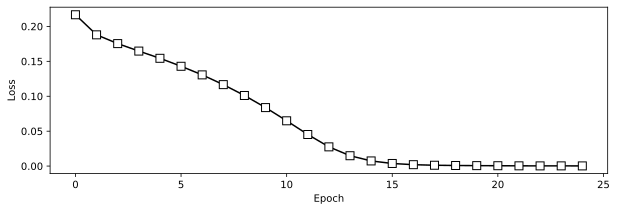

In [27]:
# train the model!
model,total_loss = trainTheModel(model) # using default 25 epochs

# plot the losses
plt.figure(figsize=(10,3))
plt.plot(total_loss,'ks-',markerfacecolor='w',markersize=8)
plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()

In [28]:
# get a copy of the trained weights
postrained_embeddings = model.embeddings.weight.detach().cpu().clone()

In [29]:
postrained_embeddings.shape

torch.Size([4589, 100])

In [30]:
total_loss.shape

(25,)

In [31]:
postrained_embeddings.flatten().shape

torch.Size([458900])

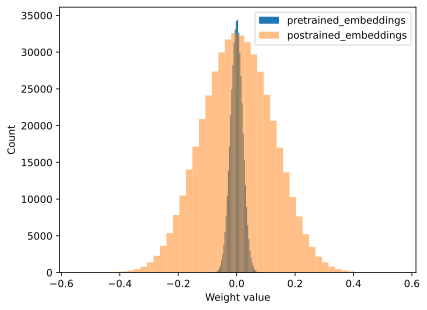

In [32]:
n_bins = 50
plt.hist(pretrained_embeddings.flatten(),n_bins,alpha=1,label='pretrained_embeddings')
plt.hist(postrained_embeddings.flatten(),n_bins,alpha=.5,label='postrained_embeddings')
plt.xlabel('Weight value')
plt.ylabel('Count')
plt.legend()
plt.show()

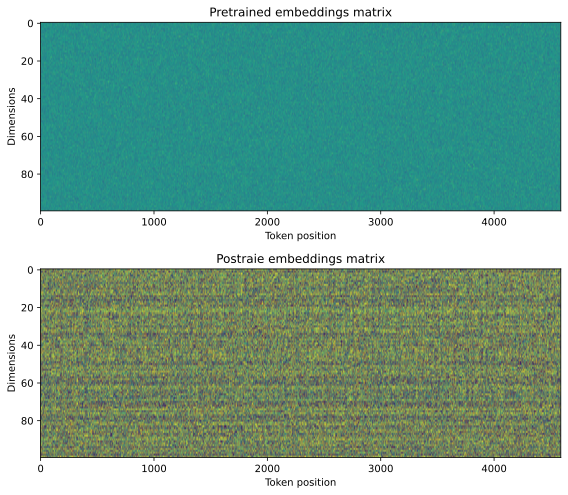

In [33]:
_,axs = plt.subplots(2,1,figsize=(8,7))

axs[0].imshow(pretrained_embeddings.T,aspect='auto',vmin=-.1,vmax=.1)
axs[0].set(xlabel='Token position',ylabel='Dimensions',title='Pretrained embeddings matrix')

axs[1].imshow(postrained_embeddings.T,aspect='auto',vmin=-.1,vmax=.1)
axs[1].set(xlabel='Token position',ylabel='Dimensions',title='Postraie embeddings matrix')


plt.tight_layout()
plt.show()

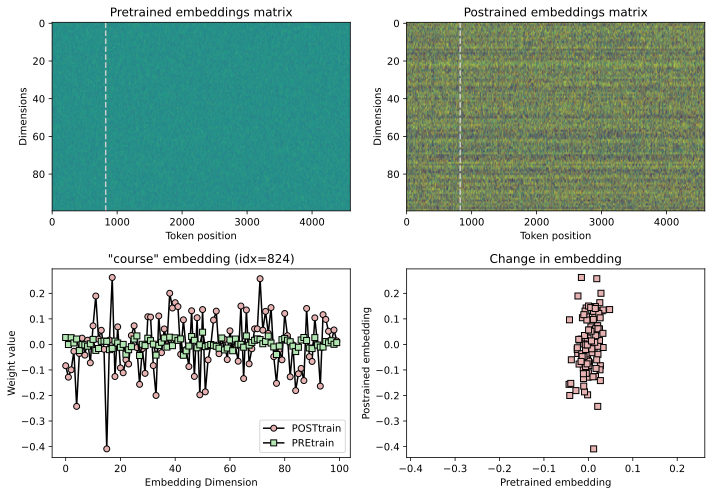

In [34]:
from matplotlib.gridspec import GridSpec

rand_word = np.random.choice(vocab)
rand_idx = word2idx[rand_word]

# setup the figure subplot geometry
fig = plt.figure(figsize=(10,7))
gs = GridSpec(2,2)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])

ax0.imshow(pretrained_embeddings.T,aspect='auto',vmin=-.1,vmax=.1)
ax0.set(xlabel='Token position',ylabel='Dimensions',title='Pretrained embeddings matrix')
ax0.axvline(rand_idx,linestyle='--',color=[.8,.8,.8])

ax1.imshow(postrained_embeddings.T,aspect='auto',vmin=-.1,vmax=.1)
ax1.set(xlabel='Token position',ylabel='Dimensions',title='Postrained embeddings matrix')
ax1.axvline(rand_idx,linestyle='--',color=[.8,.8,.8])

ax2.plot(postrained_embeddings[rand_idx],'ko-',markerfacecolor=[.9,.7,.7],label='POSTtrain')
ax2.plot(pretrained_embeddings[rand_idx],'ks-',markerfacecolor=[.7,.9,.7],label='PREtrain')
ax2.legend()
ax2.set(xlabel='Embedding Dimension',ylabel='Weight value',title=f'"{rand_word}" embedding (idx={rand_idx})')

ax3.plot(pretrained_embeddings[rand_idx],postrained_embeddings[rand_idx],'ks',markerfacecolor=[.9,.7,.7])
ax3.set(xlabel='Pretrained embedding',ylabel='Postrained embedding',title='Change in embedding',xlim=[postrained_embeddings[rand_idx][np.argmin(postrained_embeddings[rand_idx])],postrained_embeddings[rand_idx][np.argmax(postrained_embeddings[rand_idx])]])

plt.tight_layout()

plt.show()

In [35]:
rand_word.item()

'course'

In [36]:
pretrained_embeddings[rand_idx].shape

torch.Size([100])

In [37]:
np.argmin(postrained_embeddings[rand_idx])

tensor(15)

In [38]:
# pretrained_embeddings[wrd1_idx].flatten()

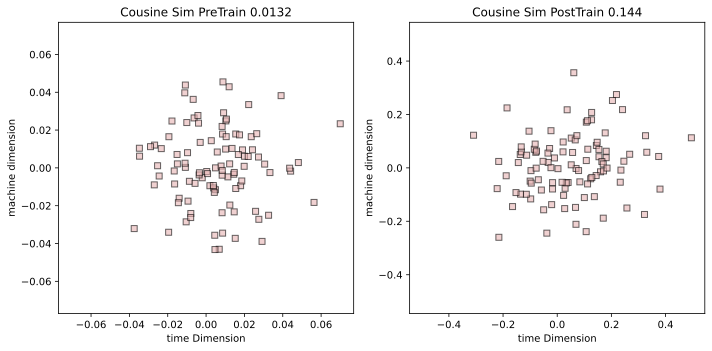

In [39]:
word1 = 'time'
word2 = 'machine'

wrd1_idx = word2idx[word1]
wrd2_idx = word2idx[word2]

# setup the figure subplot geometry
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1,2)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])

pre_cos = np.corrcoef(pretrained_embeddings[wrd1_idx],pretrained_embeddings[wrd2_idx])[0,1]
pst_cos = np.corrcoef(postrained_embeddings[wrd1_idx],postrained_embeddings[wrd2_idx])[0,1]

ax0.plot(pretrained_embeddings[wrd1_idx].flatten(),pretrained_embeddings[wrd2_idx].flatten(),'ks',markerfacecolor=[.9,.7,.7],alpha=.6)
xlim = max(abs(max(pretrained_embeddings[wrd1_idx])),abs(max(pretrained_embeddings[wrd2_idx]))) * 1.1
ax0.set(xlim=[-xlim,xlim],ylim=[-xlim,xlim],xlabel='time Dimension',ylabel='machine dimension', title=f'Cousine Sim PreTrain {pre_cos:.3}')
ax1.plot(postrained_embeddings[wrd1_idx].flatten(),postrained_embeddings[wrd2_idx].flatten(),'ks',markerfacecolor=[.9,.7,.7],alpha=.6)
xlim = max(abs(max(postrained_embeddings[wrd1_idx])),abs(max(postrained_embeddings[wrd2_idx]))) * 1.1
ax1.set(xlim=[-xlim,xlim],ylim=[-xlim,xlim],xlabel='time Dimension',ylabel='machine dimension',title=f'Cousine Sim PostTrain {pst_cos:.3}')

plt.tight_layout()

plt.show()

In [40]:
manual_cs = (pretrained_embeddings[wrd1_idx] * pretrained_embeddings[wrd2_idx])/(np.sqrt(sum(pretrained_embeddings[wrd1_idx]**2)) * np.sqrt(sum(pretrained_embeddings[wrd2_idx]**2)))
print(sum(manual_cs))
# manual_cs.shape

tensor(0.0236)


/tmp/ipykernel_25/1309485188.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  manual_cs = (pretrained_embeddings[wrd1_idx] * pretrained_embeddings[wrd2_idx])/(np.sqrt(sum(pretrained_embeddings[wrd1_idx]**2)) * np.sqrt(sum(pretrained_embeddings[wrd2_idx]**2)))


In [41]:
manual_cs = (postrained_embeddings[wrd1_idx] * postrained_embeddings[wrd2_idx])/(np.sqrt(sum(postrained_embeddings[wrd1_idx]**2)) * np.sqrt(sum(postrained_embeddings[wrd2_idx]**2)))
print(sum(manual_cs))


tensor(0.1637)


/tmp/ipykernel_25/773815332.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  manual_cs = (postrained_embeddings[wrd1_idx] * postrained_embeddings[wrd2_idx])/(np.sqrt(sum(postrained_embeddings[wrd1_idx]**2)) * np.sqrt(sum(postrained_embeddings[wrd2_idx]**2)))


In [42]:
import torch.nn.functional as F


cs_pyt = F.cosine_similarity(pretrained_embeddings[wrd2_idx].view(1,-1),pretrained_embeddings[wrd1_idx].view(1,-1))
print(cs_pyt)

tensor([0.0236])


In [43]:
pretrained_embeddings[wrd2_idx].view(1,-1).shape

torch.Size([1, 100])

In [44]:
pretrained_embeddings[wrd1_idx]

tensor([-0.0080, -0.0140,  0.0273,  0.0326,  0.0563, -0.0375,  0.0091,  0.0236,
         0.0180, -0.0108, -0.0348,  0.0086,  0.0049,  0.0242,  0.0152, -0.0020,
        -0.0164, -0.0067,  0.0102, -0.0178,  0.0058,  0.0155, -0.0036,  0.0306,
         0.0049, -0.0087,  0.0045, -0.0062, -0.0245,  0.0275,  0.0441, -0.0108,
        -0.0150, -0.0195,  0.0190,  0.0020, -0.0110,  0.0186,  0.0292,  0.0200,
         0.0103,  0.0333, -0.0031,  0.0135, -0.0097, -0.0111, -0.0151,  0.0258,
        -0.0035,  0.0144,  0.0220,  0.0436, -0.0166,  0.0123,  0.0084,  0.0391,
         0.0120, -0.0268, -0.0145, -0.0042, -0.0100, -0.0194,  0.0069,  0.0124,
         0.0114,  0.0481,  0.0040, -0.0234,  0.0199,  0.0084,  0.0084,  0.0168,
        -0.0094, -0.0104,  0.0043,  0.0105,  0.0155, -0.0058, -0.0039, -0.0080,
         0.0046,  0.0700,  0.0174,  0.0147,  0.0003,  0.0008,  0.0078, -0.0253,
        -0.0270,  0.0027,  0.0264,  0.0086, -0.0347,  0.0222,  0.0088,  0.0106,
         0.0147, -0.0290,  0.0038,  0.00

In [45]:
pretrained_embeddings[wrd1_idx]**2

tensor([6.3232e-05, 1.9713e-04, 7.4759e-04, 1.0631e-03, 3.1711e-03, 1.4054e-03,
        8.3426e-05, 5.5506e-04, 3.2436e-04, 1.1647e-04, 1.2099e-03, 7.4028e-05,
        2.3780e-05, 5.8573e-04, 2.3152e-04, 4.0310e-06, 2.6908e-04, 4.5197e-05,
        1.0414e-04, 3.1654e-04, 3.4159e-05, 2.3977e-04, 1.3124e-05, 9.3395e-04,
        2.4309e-05, 7.5541e-05, 2.0544e-05, 3.9033e-05, 5.9872e-04, 7.5753e-04,
        1.9456e-03, 1.1656e-04, 2.2363e-04, 3.8140e-04, 3.6113e-04, 3.9851e-06,
        1.2021e-04, 3.4707e-04, 8.5209e-04, 4.0130e-04, 1.0639e-04, 1.1101e-03,
        9.3640e-06, 1.8346e-04, 9.3558e-05, 1.2329e-04, 2.2896e-04, 6.6672e-04,
        1.1978e-05, 2.0871e-04, 4.8315e-04, 1.9003e-03, 2.7611e-04, 1.5123e-04,
        7.0067e-05, 1.5313e-03, 1.4464e-04, 7.2072e-04, 2.0884e-04, 1.7956e-05,
        1.0098e-04, 3.7570e-04, 4.7078e-05, 1.5385e-04, 1.2973e-04, 2.3172e-03,
        1.5775e-05, 5.4584e-04, 3.9483e-04, 7.0434e-05, 6.9764e-05, 2.8331e-04,
        8.8604e-05, 1.0793e-04, 1.8582e-

In [46]:
np.sqrt(sum((3**2,2**2,0**2,5**2)))

np.float64(6.164414002968976)

In [47]:
postrained_embeddings[rand_idx][80]

tensor(0.1211)

In [48]:
total_loss.shape

(25,)

In [49]:
model.embeddings.weight.detach().shape

torch.Size([4589, 100])

In [50]:
n_models = 10
num_epochs = 15

sp_0 = model.embeddings.weight.detach().shape[0]
sp_1 = model.embeddings.weight.detach().shape[1]
all_losses = np.zeros((n_models,num_epochs))
all_embeddings = np.zeros((n_models,sp_0,sp_1))
print(all_embeddings.shape)

for i in range(n_models):
    # we'll use the GPU for speed
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    print(f'Model {i+1}/{n_models}')
    # create a model instance!
    model = EmbeddingModel(vocab_size=nVocab, embedding_dim=embeddingDimension, context_size=context_length)
    # print(model)

    # apply Xavier weight distribution
    for param in model.parameters():
        if param.dim()>1: # also excludes biases
            nn.init.xavier_normal_(param)

    # and move it to the GPU
    model = model.to(device)

    # create the loss and optimizer functions
    loss_function = nn.NLLLoss().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

    # train the model!
    model,total_loss = trainTheModel(model,num_epochs) # using default 25 epochs
    postrained_embeddings = model.embeddings.weight.detach().cpu().clone()
    all_embeddings[i] = postrained_embeddings
    all_losses[i] = total_loss



(10, 4589, 100)
Using device: cuda
Model 1/10
  Finished epoch 1 with loss 0.2175
  Finished epoch 2 with loss 0.1883
  Finished epoch 3 with loss 0.1759
  Finished epoch 4 with loss 0.1650
  Finished epoch 5 with loss 0.1541
  Finished epoch 6 with loss 0.1428
  Finished epoch 7 with loss 0.1305
  Finished epoch 8 with loss 0.1168
  Finished epoch 9 with loss 0.1016
  Finished epoch 10 with loss 0.0849
  Finished epoch 11 with loss 0.0665
  Finished epoch 12 with loss 0.0475
  Finished epoch 13 with loss 0.0296
  Finished epoch 14 with loss 0.0162
  Finished epoch 15 with loss 0.0082
Using device: cuda
Model 2/10


/tmp/ipykernel_25/927313831.py:34: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  all_embeddings[i] = postrained_embeddings


  Finished epoch 1 with loss 0.2172
  Finished epoch 2 with loss 0.1875
  Finished epoch 3 with loss 0.1744
  Finished epoch 4 with loss 0.1639
  Finished epoch 5 with loss 0.1539
  Finished epoch 6 with loss 0.1430
  Finished epoch 7 with loss 0.1308
  Finished epoch 8 with loss 0.1171
  Finished epoch 9 with loss 0.1016
  Finished epoch 10 with loss 0.0844
  Finished epoch 11 with loss 0.0654
  Finished epoch 12 with loss 0.0459
  Finished epoch 13 with loss 0.0281
  Finished epoch 14 with loss 0.0154
  Finished epoch 15 with loss 0.0081
Using device: cuda
Model 3/10
  Finished epoch 1 with loss 0.2167
  Finished epoch 2 with loss 0.1884
  Finished epoch 3 with loss 0.1764
  Finished epoch 4 with loss 0.1663
  Finished epoch 5 with loss 0.1561
  Finished epoch 6 with loss 0.1450
  Finished epoch 7 with loss 0.1328
  Finished epoch 8 with loss 0.1192
  Finished epoch 9 with loss 0.1038
  Finished epoch 10 with loss 0.0865
  Finished epoch 11 with loss 0.0679
  Finished epoch 12 with l

In [51]:
j = model.embeddings.weight.detach()
j.shape

torch.Size([4589, 100])

In [52]:
all_losses[0].shape

(15,)

In [53]:
total_loss[:15].shape

(15,)

In [54]:
# plt.plot(all_losses[i],'ks',markerfacecolor='w',markersize=8)

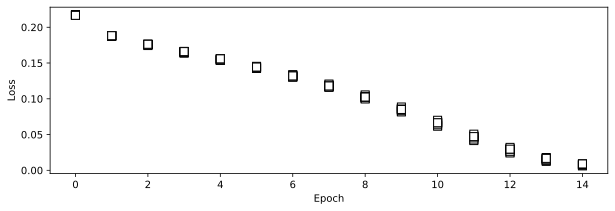

In [55]:
# plot the losses
plt.figure(figsize=(10,3))

for i in range(n_models):
    plt.plot(all_losses[i],'ks',markerfacecolor='w',markersize=8)

plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()

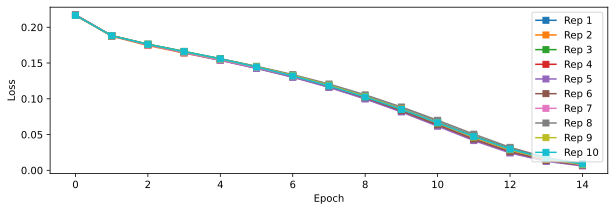

In [56]:
# plot the losses
plt.figure(figsize=(10,3))

for i in range(n_models):
    plt.plot(all_losses[i],'s-',label=f"Rep {i+1}")

plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.legend()
plt.show()

In [57]:
# Plenty of empty space so you won't look by accident :P

# **Code below is for video "CodeChallenge: How the embeddings change"**

## Exercise 1: distributions of embeddings

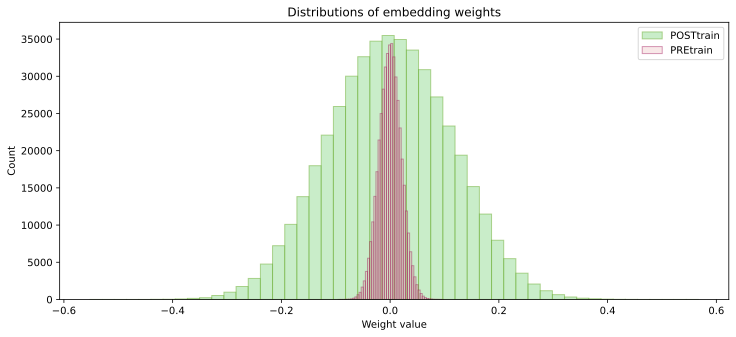

In [58]:
# histograms via numpy
yPre,xPre = np.histogram(pretrained_embeddings.flatten(),bins=50)
yPst,xPst = np.histogram(postrained_embeddings.flatten(),bins=50)

# recalculate x values as bin centers
xPre = (xPre[1:]+xPre[:-1]) / 2
xPst = (xPst[1:]+xPst[:-1]) / 2

# and plot
plt.figure(figsize=(12,5))
plt.bar(xPst,yPst,width=xPst[1]-xPst[0],color=[.7,.9,.7,.7],edgecolor=[.3,.6,0,.4],label='POSTtrain')
plt.bar(xPre,yPre,width=xPre[1]-xPre[0],color=[.9,.7,.7,.3],edgecolor=[.6,0,.3,.4],label='PREtrain')

plt.gca().set(xlabel='Weight value',ylabel='Count',title='Distributions of embedding weights')
plt.legend()
plt.show()

## Exercise 2: Embeddings vectors for a random word

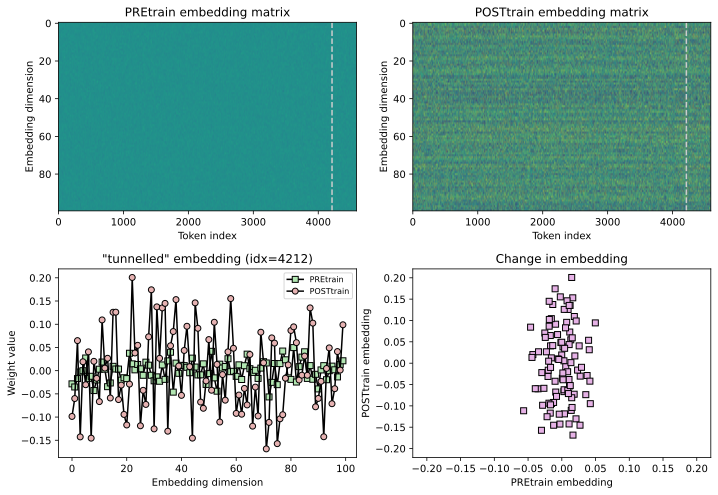

In [59]:
# pick a word at random
aRandomWord = np.random.choice(vocab)
randWord_idx = word2idx[aRandomWord]

# extract its embeddings vectors
pre_ev = pretrained_embeddings[randWord_idx,:]
pst_ev = postrained_embeddings[randWord_idx,:]



_,axs = plt.subplots(2,2,figsize=(10,7))

# the pretrainined embeddings
axs[0,0].imshow(pretrained_embeddings.T,aspect='auto',vmin=-.2,vmax=.2)
axs[0,0].set(ylabel='Embedding dimension',xlabel='Token index',title='PREtrain embedding matrix')

# the post-trainined embeddings
axs[0,1].imshow(postrained_embeddings.T,aspect='auto',vmin=-.2,vmax=.2)
axs[0,1].set(ylabel='Embedding dimension',xlabel='Token index',title='POSTtrain embedding matrix')


axs[0,0].axvline(randWord_idx,linestyle='--',color=[.8,.8,.8])
axs[0,1].axvline(randWord_idx,linestyle='--',color=[.8,.8,.8])

# plot its embedding
axs[1,0].plot(pre_ev,'ks-',markerfacecolor=[.7,.9,.7],label='PREtrain')
axs[1,0].plot(pst_ev,'ko-',markerfacecolor=[.9,.7,.7],label='POSTtrain')
axs[1,0].set(xlabel='Embedding dimension',ylabel='Weight value',title=f'"{aRandomWord}" embedding (idx={randWord_idx})')
axs[1,0].legend(fontsize=8)

# how it changed
axlim = max(abs(pre_ev).max(),abs(pst_ev).max()) * 1.1 # equal axis limits
axs[1,1].plot(pre_ev,pst_ev,'ks',markerfacecolor=[.9,.7,.9])
axs[1,1].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel='PREtrain embedding',
             ylabel='POSTtrain embedding',title='Change in embedding')

plt.tight_layout()
plt.show()

## Exercise 3: Time Machine embeddings

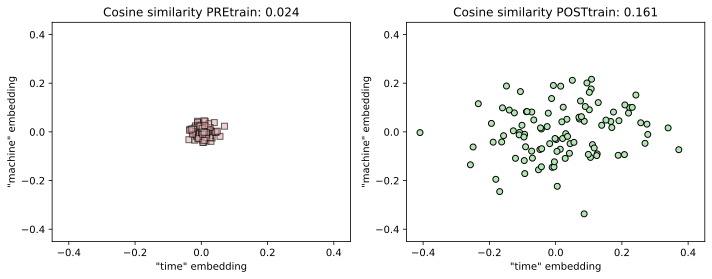

In [60]:
# embeddings for closely related words
word1 = 'time'
word2 = 'machine'

# their embeddings
embed1pre = pretrained_embeddings[word2idx[word1],:]
embed2pre = pretrained_embeddings[word2idx[word2],:]
embed1pst = postrained_embeddings[word2idx[word1],:]
embed2pst = postrained_embeddings[word2idx[word2],:]

# cosine similarity between them
cosSim_pre = F.cosine_similarity(embed1pre.unsqueeze(dim=0),embed2pre.view(1,-1))
cosSim_pst = nn.functional.cosine_similarity(embed1pst.unsqueeze(dim=0),embed2pst.view(1,-1))


# vizualize
_,axs = plt.subplots(1,2,figsize=(10,4))

axlim = torch.cat((abs(embed1pre),abs(embed2pre),abs(embed1pst),abs(embed2pst))).max() * 1.1
axs[0].plot(embed1pre,embed2pre,'ks',markerfacecolor=[.9,.7,.7],alpha=.6)
axs[0].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel=f'"{word1}" embedding',
           ylabel=f'"{word2}" embedding',title=f'Cosine similarity PREtrain: {cosSim_pre.item():.3f}')

axs[1].plot(embed1pst,embed2pst,'ko',markerfacecolor=[.7,.9,.7])
axs[1].set(xlim=[-axlim,axlim],ylim=[-axlim,axlim],xlabel=f'"{word1}" embedding',
           ylabel=f'"{word2}" embedding',title=f'Cosine similarity POSTtrain: {cosSim_pst.item():.3f}')

plt.tight_layout()
plt.show()

In [61]:
axlim == xlim

tensor(False)

In [62]:
-axlim == -xlim

tensor(False)

In [63]:
# cosine similarity manually
num = torch.dot(embed1pst,embed2pst)
den = torch.norm(embed1pst)*torch.norm(embed2pst)
cs_man = num / den

# and via pytorch
cs_pyt = F.cosine_similarity(embed2pst.unsqueeze(dim=0),embed1pst.view(1,-1))

print(f'Cosine similarity from numpy: {cs_man:.4f}')
print(f'Cosine similarity from torch: {cs_pyt.item():.4f}')

Cosine similarity from numpy: 0.1613
Cosine similarity from torch: 0.1613


# **Code below is for video "CodeChallenge: How stable are embeddings?"**

## Exercise 1: New training, different weights

In [64]:
# number of repetitions (new models) and epochs
numRepetitions = 10
numEpochs = 16

# initializations
lossesMatrix = np.zeros((numRepetitions,numEpochs))
embeddingsMats = []

# loop over repetitions
for repi in range(numRepetitions):

  # create a new model
  model = EmbeddingModel(vocab_size=nVocab, embedding_dim=embeddingDimension, context_size=context_length)
  model = model.to(device)
  for param in model.parameters():
    if param.dim()>1: nn.init.xavier_normal_(param)

  # need to recreate the optimizer b/c it retains gradient/overhead info
  optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

  # train the model
  print(f'** Running repetition {repi+1}/{numRepetitions} **')
  model,total_loss = trainTheModel(model,numEpochs)
  print('\n')

  # get its losses
  lossesMatrix[repi,:] = total_loss

  # extract the embedding matrix
  embeddingsMats.append( model.embeddings.weight.detach().cpu() )

** Running repetition 1/10 **
  Finished epoch 1 with loss 0.2168
  Finished epoch 2 with loss 0.1879
  Finished epoch 3 with loss 0.1752
  Finished epoch 4 with loss 0.1647
  Finished epoch 5 with loss 0.1545
  Finished epoch 6 with loss 0.1432
  Finished epoch 7 with loss 0.1307
  Finished epoch 8 with loss 0.1168
  Finished epoch 9 with loss 0.1009
  Finished epoch 10 with loss 0.0834
  Finished epoch 11 with loss 0.0641
  Finished epoch 12 with loss 0.0442
  Finished epoch 13 with loss 0.0265
  Finished epoch 14 with loss 0.0142
  Finished epoch 15 with loss 0.0072
  Finished epoch 16 with loss 0.0037


** Running repetition 2/10 **
  Finished epoch 1 with loss 0.2169
  Finished epoch 2 with loss 0.1876
  Finished epoch 3 with loss 0.1745
  Finished epoch 4 with loss 0.1637
  Finished epoch 5 with loss 0.1535
  Finished epoch 6 with loss 0.1428
  Finished epoch 7 with loss 0.1310
  Finished epoch 8 with loss 0.1176
  Finished epoch 9 with loss 0.1022
  Finished epoch 10 with loss 0

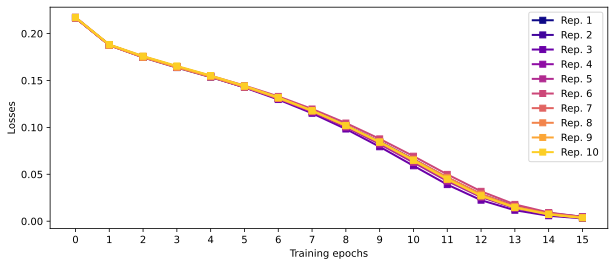

In [65]:
# plot the losses
plt.figure(figsize=(10,4))

# in a for-loop to get different colors
for i in range(numRepetitions):
  plt.plot(lossesMatrix[i,:],'s-',linewidth=2,color=mpl.cm.plasma(i/numRepetitions),label=f'Rep. {i+1}')

plt.legend()
plt.gca().set(xticks=range(numEpochs),xlabel='Training epochs',ylabel='Losses')
plt.show()

## Exercise 2: Consistency of embedding vectors

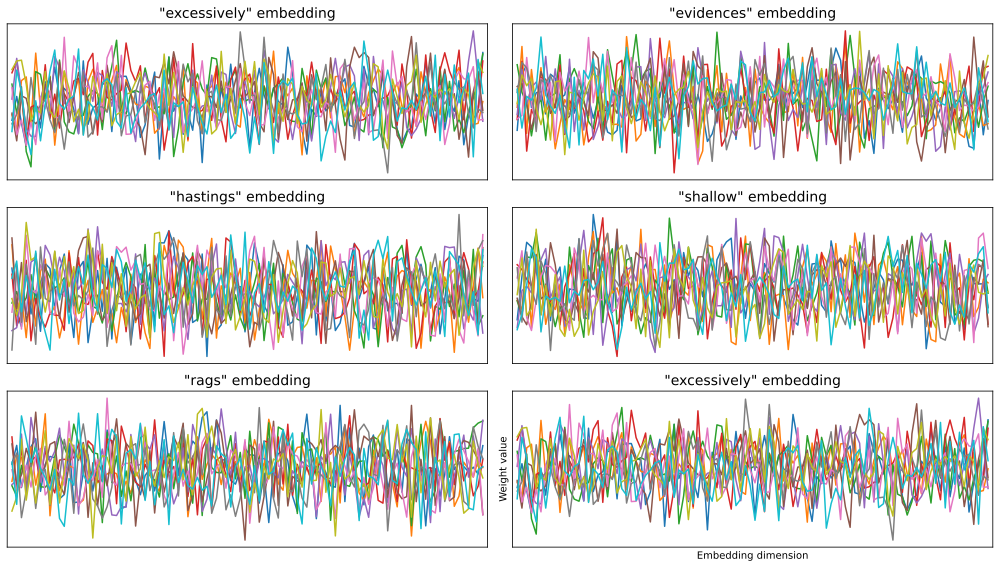

In [66]:
_,axs = plt.subplots(3,2,figsize=(14,8))

# random words
randWords = np.random.choice(vocab,size=np.prod(axs.shape))

# but what do individual embeddings look like?
for wordi,ax in enumerate(axs.flatten()):

  # index of this random word
  randWord_idx = word2idx[randWords[wordi]]

  # loop over the repetitions
  for repi in range(numRepetitions):

    # draw lines for embeddings in each repetition
    ax.plot(embeddingsMats[repi][randWord_idx,:])

  # title of this subplot
  ax.set_title(f'"{randWords[wordi]}" embedding',fontsize=14)


# final adjustments
for a in axs.flatten(): a.set(xticks=[],yticks=[],xlim=[-1,embeddingDimension])
ax.set(xlabel='Embedding dimension',ylabel='Weight value')

plt.tight_layout()
plt.show()

## Exercise 3: Cosine similarity for selected word pairs

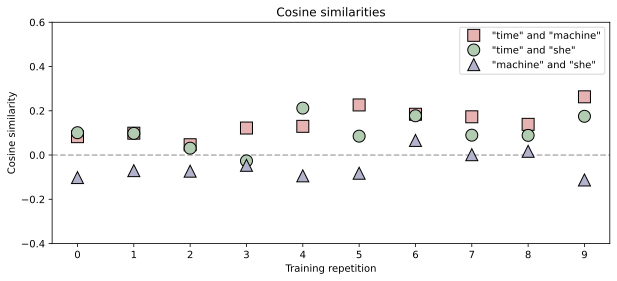

In [67]:
# pick three words
word1 = 'time'
word2 = 'machine'
word3 = 'she'

# vector of cosine similarity for each repetition
cossim = np.zeros((numRepetitions,3))

# and the for-loop!
for repi in range(numRepetitions):

  # their embeddings
  e1 = embeddingsMats[repi][word2idx[word1],:]
  e2 = embeddingsMats[repi][word2idx[word2],:]
  e3 = embeddingsMats[repi][word2idx[word3],:]

  # cosine similarity between each pair
  cossim[repi,0] = nn.functional.cosine_similarity(e1,e2.view(1,-1)).item()
  cossim[repi,1] = nn.functional.cosine_similarity(e1,e3.view(1,-1)).item()
  cossim[repi,2] = nn.functional.cosine_similarity(e2,e3.view(1,-1)).item()


# the plot
plt.figure(figsize=(10,4))
plt.plot(cossim[:,0],'ks',markerfacecolor=[.9,.7,.7],markersize=12,label=f'"{word1}" and "{word2}"')
plt.plot(cossim[:,1],'ko',markerfacecolor=[.7,.8,.7],markersize=12,label=f'"{word1}" and "{word3}"')
plt.plot(cossim[:,2],'k^',markerfacecolor=[.7,.7,.8],markersize=12,label=f'"{word2}" and "{word3}"')

plt.axhline(0,color=[.7,.7,.7],linestyle='--',zorder=-10)
plt.gca().set(xticks=range(numRepetitions),ylim=[-.4,.6],
              xlabel='Training repetition',ylabel='Cosine similarity',title='Cosine similarities')
plt.legend()

plt.show()